In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


##The code below should be run on Google Colab

In [2]:

df_train = pd.read_csv('/content/sample_data/california_housing_train.csv')
df_test = pd.read_csv("/content/sample_data/california_housing_test.csv")
X_train = np.array(df_train['median_income'])
Y_train = np.array(df_train['median_house_value'])
X_test = np.array(df_test['median_income'])
Y_test = np.array(df_test["median_house_value"])


It's important to notice that the target(Y) has many values on  its maximum - around 500000 - this will be demonstrated at the graph

In [3]:
np.max(Y_train)

np.float64(500001.0)

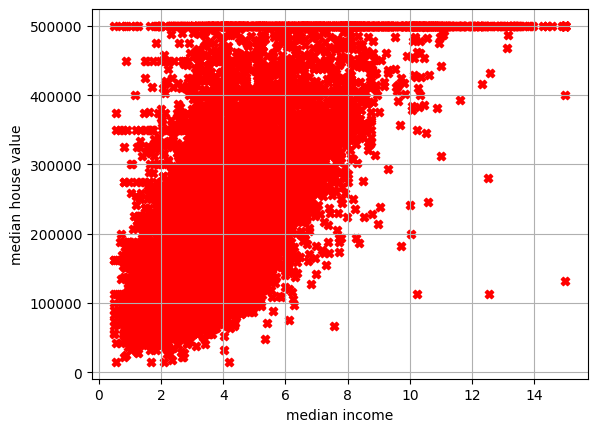

In [4]:

plt.scatter(X_train, Y_train, marker = "X", color="red")
plt.ylabel("median house value")
plt.xlabel("median income")
plt.grid(True)


In [5]:
def compute_fwb(w, b, x):

  fwb = (w*x) + b
  return fwb

In [6]:
def compute_cost(x, y, w, b):
    # m = x.shape[0]
    # cost = 0
    # for i in range(m):
    #     fwb = computar_fwb(w, b, x[i])
    #     cost += (fwb - y[i])**2
    # return cost / (2 * m)
    #versão vetorizada:

    m = x.shape[0]
    fwb = compute_fwb(w, b, x)
    cost = np.sum((fwb - y)**2)

    return cost / (2 * m)

In [7]:
def compute_partial_derivatives(x, y, w, b):
  dj_dw = 0
  dj_db = 0
  m = x.shape[0]
  # for i in range(m):
  #   fwb = computar_fwb(w, b, x[i])
  #   dj_dw += (fwb - y[i]) * x[i]
  #   dj_db += (fwb - y[i])

  # dj_db = dj_db / m
  # dj_dw = dj_dw / m
  # aplicando vetorização:

  fwb = compute_fwb(w, b, x)
  error = fwb - y
  dj_dw = np.dot(error, x) / m
  dj_db = np.sum(error) / m


  return dj_dw, dj_db


In [8]:
def compute_gd(alpha, x, y, w, b, iterations):
  cost_history = []
  last_cost = compute_cost(x, y, w, b)
  for i in range(iterations):

    dj_dw, dj_db = compute_partial_derivatives(x, y, w, b)
    tmp_w = w - alpha * dj_dw
    tmp_b = b - alpha * dj_db
    w = tmp_w
    b = tmp_b
    cost = compute_cost(x, y, w, b)
    cost_history.append(cost)
    if abs(last_cost - cost) < 1.0e-6:
      break

    if i % (iterations//10) == 0:
      print(f"iteration {i} → cost {compute_cost(x, y, w, b)}")

  plt.plot(range(iterations), cost_history)
  plt.ylabel("cost")
  plt.xlabel("iterations")

  return w, b


iteration 0 → cost 6936806491.535606
iteration 500 → cost 3506219987.7014194
iteration 1000 → cost 3506219774.4576225
iteration 1500 → cost 3506219774.4571996
iteration 2000 → cost 3506219774.4572
iteration 2500 → cost 3506219774.4572
iteration 3000 → cost 3506219774.4572
iteration 3500 → cost 3506219774.4572
iteration 4000 → cost 3506219774.4572
iteration 4500 → cost 3506219774.4572
running time 6.706629514694214


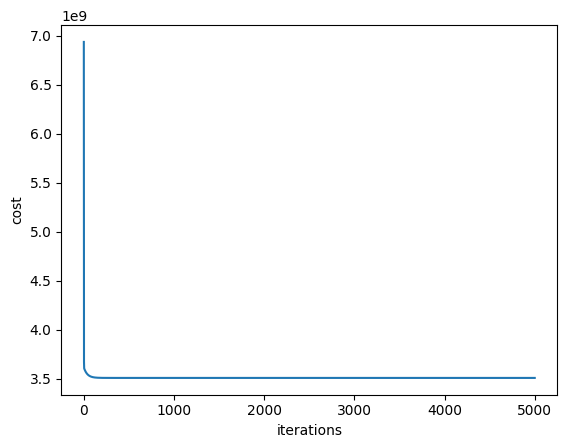

In [9]:
import time
tic = time.time()
w, b = compute_gd(0.07, X_train, Y_train, 0, 0, 5000)
toc = time.time()
print("running time", toc - tic)

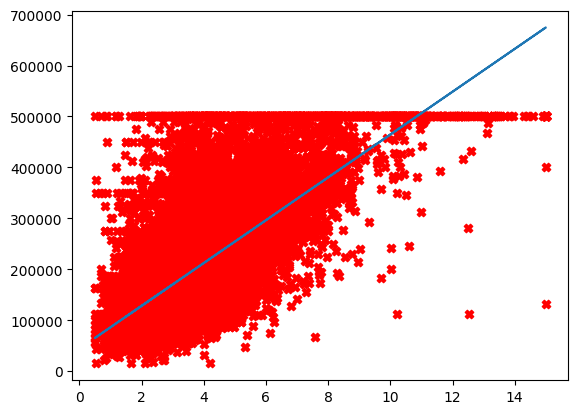

In [10]:
# predicoes = []
# for x in X_train:
#   predicoes.append(computar_fwb(w, b, x))
# plt.scatter(X_train, Y_train, color="red", marker="X")
# plt.plot(X_train, predicoes)
# plt.show()
#versão vetorizada
predictions = (compute_fwb(w, b, X_train))
plt.scatter(X_train, Y_train, color="red", marker="X")
plt.plot(X_train, predictions)
plt.show()

In [11]:

X_train_norm = (X_train - np.mean(X_train))/ np.std(X_train)
X_test_norm = np.array(X_test)
X_test_norm = (X_test_norm - np.mean(X_train))/ np.std(X_train)

print(X_train_norm, X_test_norm)

[-1.25254316 -1.08148298 -1.17010515 ... -0.44666313 -0.99778717
 -0.45536288] [ 1.42808099 -0.1491421   1.00090221 ... -0.83542674 -0.32114563
  2.45124518]


w and b before normalization:42054.0748740562, 43980.628156296225

iteration 0 → cost 23518118622.21822
iteration 500 → cost 3506219774.4572
iteration 1000 → cost 3506219774.4572
iteration 1500 → cost 3506219774.4572
iteration 2000 → cost 3506219774.4572
iteration 2500 → cost 3506219774.4572
iteration 3000 → cost 3506219774.4572
iteration 3500 → cost 3506219774.4572
iteration 4000 → cost 3506219774.4572
iteration 4500 → cost 3506219774.4572
running time: 2.991101026535034
updated w and b:80243.3968912973, 207300.9123529411



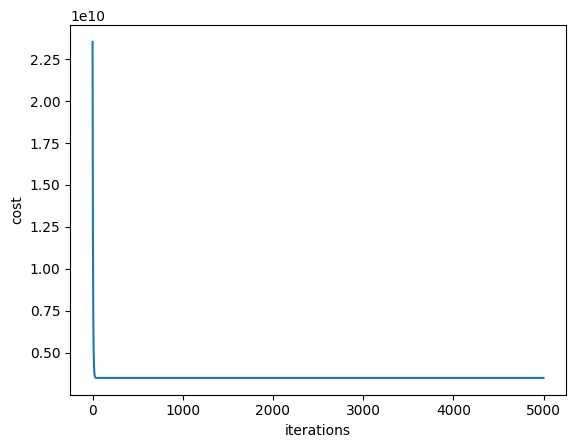

In [12]:

print(f"w and b before normalization:{w}, {b}\n")
tic = time.time()
w, b = compute_gd(0.1, X_train_norm, Y_train, 1, 1, 5000)
toc = time.time()
print("running time:", toc - tic)
print(f"updated w and b:{w}, {b}\n")

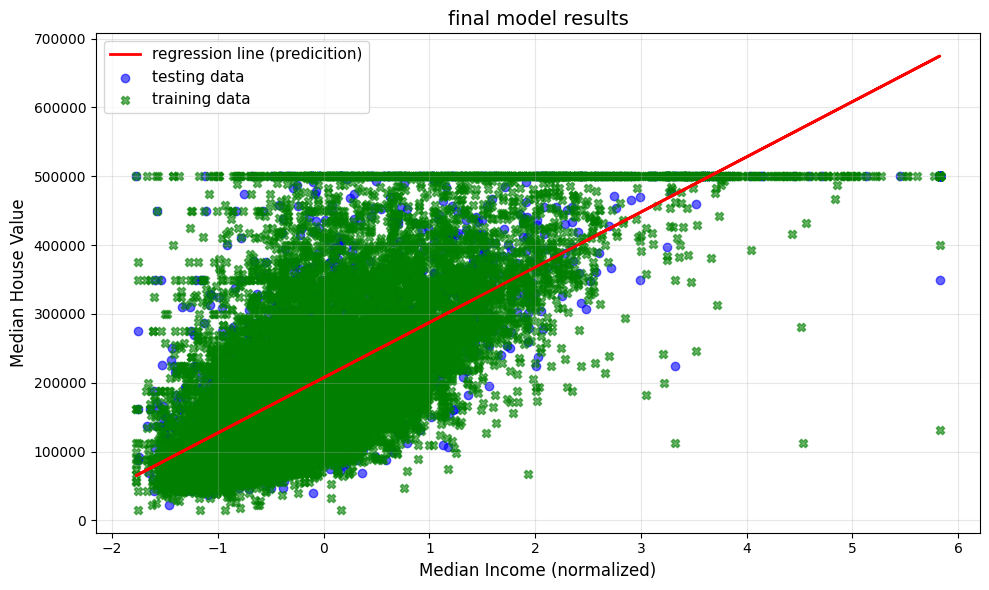

In [13]:

predictions = compute_fwb(w, b, X_test_norm)

plt.figure(figsize=(10, 6))

plt.plot(X_test_norm, predictions,
         color="red",
         linewidth=2,
         label='regression line (predicition)')

plt.scatter(X_test_norm, Y_test,
            color='blue',
            alpha=0.6,
            label='testing data')

plt.scatter(X_train_norm, Y_train,
            marker="X",
            color='green',
            alpha=0.6,
            label='training data')

plt.ylabel("Median House Value", fontsize=12)
plt.xlabel("Median Income (normalized)", fontsize=12)
plt.title('final model results', fontsize=14)

plt.legend(fontsize=11)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()